In [19]:
# Package Imports

import os
import numpy as np
import pandas as pd
import nilearn
from nilearn.glm.second_level import SecondLevelModel
from nilearn.plotting import plot_stat_map, show
from nilearn.glm import threshold_stats_img

In [21]:
# Loading Participant Data & Scans

csv_path = '/Users/grant/Desktop/BrainHackFinalProject/NIMH_Participants_Full.csv'
data_dir = '/Users/grant/Desktop/BrainHackFinalProject/NIMH_Scans/'

df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

covariates_raw = ['ACE_score', 'age', 'sex', 'TIV']
df = df.dropna(subset=['participant_id'] + covariates_raw)

if df['sex'].dtype == 'object':
    df['sex'] = pd.get_dummies(df['sex'], drop_first=True).astype(int)

gm_maps = [os.path.join(data_dir, f"{row['participant_id']}_smwc1.nii") for _, row in df.iterrows()]
missing_files = [path for path in gm_maps if not os.path.exists(path)]

print(f"Loaded {len(df)} subjects. Missing files: {len(missing_files)}")

Loaded 82 subjects. Missing files: 0


Matrix shape: (82, 5)


[SecondLevelModel.fit] Fitting second level model. Take a deep breath.

[SecondLevelModel.fit] Loading data from <nibabel.nifti1.Nifti1Image object at 0x13254fe30>

[SecondLevelModel.fit] Computing mask

[SecondLevelModel.fit] Resampling mask

...

[SecondLevelModel.fit] 
Computation of second level model done in 0.05 seconds.

[SecondLevelModel.compute_contrast] Loading data from <nibabel.nifti1.Nifti1Image object at 0x1336d6840>

[SecondLevelModel.compute_contrast] Extracting region signals

[SecondLevelModel.compute_contrast] Cleaning extracted signals

[SecondLevelModel.compute_contrast] Computing image from signals

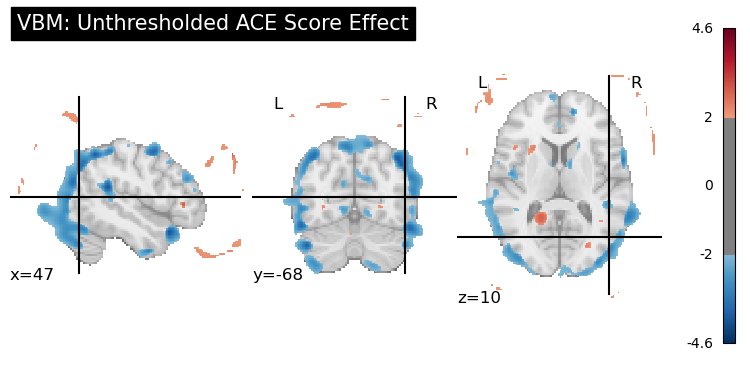

In [22]:
# Model Fitting

df['intercept'] = 1
covariates = ['ACE_score', 'age', 'sex', 'TIV', 'intercept']
design_matrix = df[covariates].apply(pd.to_numeric)

print(f"Matrix shape: {design_matrix.shape}")

model = SecondLevelModel(smoothing_fwhm=None, verbose=1)
model.fit(gm_maps, design_matrix=design_matrix)

ace_contrast = [1, 0, 0, 0, 0]
z_map = model.compute_contrast(second_level_contrast=ace_contrast, output_type='z_score')

plot_stat_map(z_map, threshold=2.0, title="VBM: Unthresholded ACE Score Effect")
show()

/var/folders/fh/58dlscq57cs6q4ryfr24bljm0000gn/T/ipykernel_14097/1032966112.py:3: UserWarning: The given float value must not exceed 4.594029888178809. But, you have given threshold=inf.
  thresholded_map, threshold_val = threshold_stats_img(


Threshold Z: inf (Fallback triggered: True)


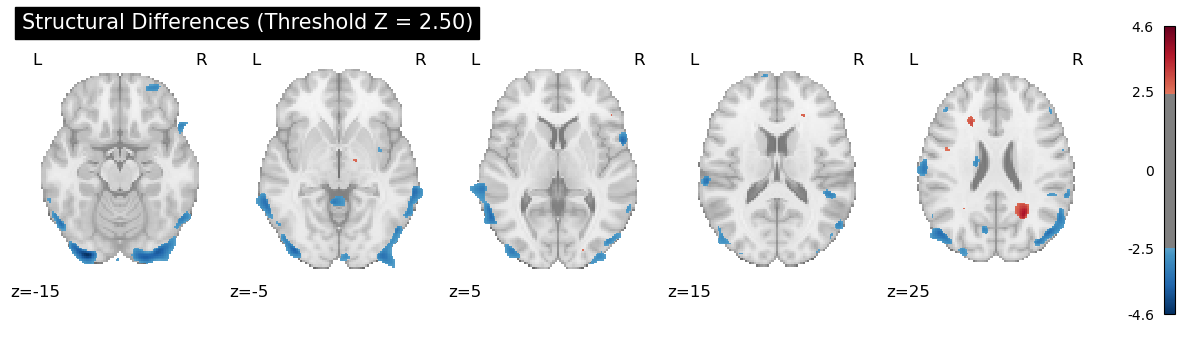

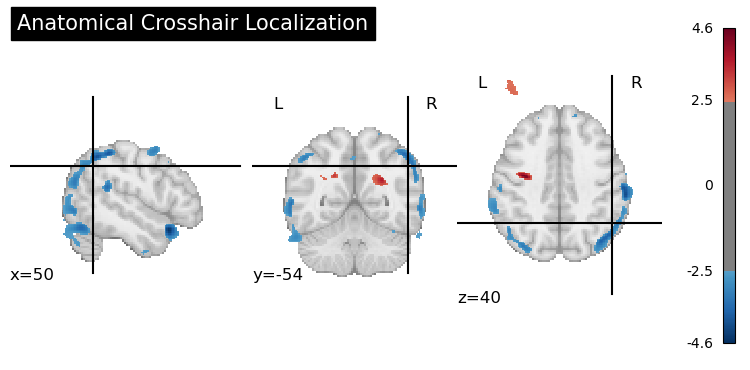

In [23]:
# Statistical Testing

thresholded_map, threshold_val = threshold_stats_img(
    z_map, 
    alpha=0.05, 
    height_control='fdr', 
    cluster_threshold=10
)

is_empty = np.isinf(threshold_val)
plot_threshold = 2.5 if is_empty else threshold_val
map_to_plot = z_map if is_empty else thresholded_map

print(f"Threshold Z: {threshold_val} (Fallback triggered: {is_empty})")

plot_stat_map(
    map_to_plot, 
    threshold=plot_threshold, 
    display_mode='z',       
    cut_coords=[-15, -5, 5, 15, 25],  
    title=f"Structural Differences (Threshold Z = {plot_threshold:.2f})"
)
show()

plot_stat_map(
    map_to_plot, 
    threshold=plot_threshold, 
    draw_cross=True, 
    annotate=True,
    colorbar=True,
    title="Anatomical Crosshair Localization"
)
show()